# PlantSR x2 — Pretrained Super-Resolution Inference on the PlantSR Test Split

Reproduction of the inference part of **PlantSR: Super-Resolution Improves Object Detection in Plant Images**
(*Journal of Imaging* 2024, 10(6):137, doi:[10.3390/jimaging10060137](https://doi.org/10.3390/jimaging10060137), PMCID PMC11204869).

**Scope (single-example experience).** We load the authors' PlantSR ×2 pretrained checkpoint and run their exact
test-time protocol (`test.ipynb`, "## test PlantSR" cells; repo pinned at commit
`a514452972806aaaf643a111e2d328eb8feb460e`) on a small deterministic subset of the PlantSR test split
([figshare 24648150](https://figshare.com/articles/dataset/PlantSR_Dataset/24648150), CC BY 4.0):
low-resolution input generation, ×2 super-resolution, PSNR/SSIM with the authors' own metric code
(`calulate_psnr_ssim.py`), the bicubic baseline, and a labeled visual comparison.

**Not covered.** Training, the full 200-image Table 1 benchmark, and the apple/soybean counting branches
are out of scope. The subset PSNR/SSIM below is an *indicative* check against the paper's 200-image
averages, not a reproduction of Table 1.

**実行内容(日本語):** 著者公開の PlantSR ×2 学習済み重みを読み込み、著者のテスト用プロトコルに従い、
PlantSR データセットのテスト画像サブセットで超解像推論と PSNR/SSIM(bicubic 比較付き)を実行します。
学習および Table 1 のフルベンチマーク、リンゴ/大豆のカウント実験は範囲外です。

## Runtime selection

This demo performs **inference only** with a lightweight ~1.4 M-parameter CNN, so **CPU is sufficient and is the
recommended runtime** (`Runtime` → `Change runtime type` → `CPU`). If a GPU (T4) is allocated instead, the notebook
detects it automatically and runs the same scientific path on `cuda:0`; results are identical up to floating-point
noise. No `pip install` is needed — torch, OpenCV, numpy and matplotlib are preinstalled in Colab.

**Expected cost (estimates, not measurements):** ~228 MB dataset zip + ~80 MB weights zip downloads, then a few
minutes of inference for the small subset. Total ≲ 15 min on CPU.

**実行環境(日本語):** CPU 推奨(軽量モデルの推論のみのため)。GPU(T4)でも自動検出して同一処理を実行します。
追加の pip インストールは不要です。

In [ ]:
import os, sys, platform
import numpy as np
import torch
import cv2
import matplotlib

print("python:", sys.version.split()[0])
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("cv2:", cv2.__version__)
print("numpy:", np.__version__)
print("device used later:", "cuda:0" if torch.cuda.is_available() else "cpu")

python: 3.13.16
torch: 2.11.0+cpu | cuda available: False
cv2: 5.0.0
numpy: 2.1.3
device used later: cpu


## Step 1 — Acquire the PlantSR dataset (test split)

The PlantSR dataset (1030 high-resolution plant images; 830 train / 200 test) is published on figshare
(record [24648150](https://figshare.com/articles/dataset/PlantSR_Dataset/24648150), version v1,
doi:10.6084/m9.figshare.24648150.v1, **CC BY 4.0**). The record API lists a single file
`PlantSR_dataset.zip` (228,049,963 bytes, md5 `091964e3e7cd94435c1e499722fde9c2`), which we download
in full, verify against the published md5, and extract under `/content` (Colab VM only).

**日本語:** figshare の PlantSR データセット(CC BY 4.0)をダウンロードし、公開されている md5 を検証してから展開します。

In [ ]:
import hashlib, zipfile, requests

DATASET_URL = "https://ndownloader.figshare.com/files/43316565"  # PlantSR_dataset.zip, figshare record 24648150 v1
DATASET_MD5 = "091964e3e7cd94435c1e499722fde9c2"
ZIP_PATH = "/content/PlantSR_dataset.zip"
EXTRACT_DIR = "/content/PlantSR_dataset"

if not os.path.exists(ZIP_PATH):
    with requests.get(DATASET_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        with open(ZIP_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

h = hashlib.md5()
with open(ZIP_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
assert h.hexdigest() == DATASET_MD5, f"md5 mismatch: got {h.hexdigest()}"
print(f"PlantSR_dataset.zip: {os.path.getsize(ZIP_PATH):,} bytes, md5 OK")

if not os.path.isdir(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH) as z:
        for member in z.infolist():  # safe extraction: reject absolute/.. paths
            assert not member.filename.startswith("/") and ".." not in member.filename.split("/")
            z.extract(member, EXTRACT_DIR)

for root, dirs, files in os.walk(EXTRACT_DIR):
    n_img = sum(f.lower().endswith((".png", ".jpg", ".jpeg")) for f in files)
    if n_img:
        print(f"{root}: {n_img} images")

PlantSR_dataset.zip: 228,049,963 bytes, md5 OK


/content/PlantSR_dataset/PlantSR_dataset/train: 830 images
/content/PlantSR_dataset/PlantSR_dataset/test: 200 images


## Step 2 — Acquire the pretrained PlantSR ×2 checkpoint

The README of the pinned repository links "Pretrained models" to a public Dropbox folder. Its file listing
(recorded from folder metadata) contains exactly three checkpoints: `PlantSR_x2_best.pth` (5,764,873 bytes),
`PlantSR_x3_best.pth` and `PlantSR_x4_best.pth`. We download the folder archive, extract **only** the ×2
checkpoint, verify its size, and inspect the state-dict keys/shapes (without dumping weight values).

**日本語:** 著者 README からリンクされた公開 Dropbox フォルダから ×2 用チェックポイントのみを取得し、
サイズと state_dict のキー形状を検証します(重みの中身自体は表示しません)。

In [ ]:
DROPBOX_URL = "https://www.dropbox.com/scl/fo/k3xqyu3zomu3insdqydnz/h?rlkey=8mwov9xap0bwsvou0dui7drsq&dl=1"
CKPT_NAME = "PlantSR_x2_best.pth"
CKPT_BYTES = 5_764_873  # recorded from the folder metadata listing
CKPT_PATH = "/content/PlantSR_x2_best.pth"

WZIP_PATH = "/content/PlantSR_pretrained_models.zip"
if not os.path.exists(CKPT_PATH):
    with requests.get(DROPBOX_URL, stream=True, timeout=900) as r:
        r.raise_for_status()
        with open(WZIP_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

with open(WZIP_PATH, "rb") as f:
    magic = f.read(4)
assert magic == b"PK\x03\x04", f"not a zip archive (magic={magic!r})"

with zipfile.ZipFile(WZIP_PATH) as z:
    members = [m for m in z.infolist() if os.path.basename(m.filename) == CKPT_NAME]
    assert len(members) == 1, f"expected exactly one {CKPT_NAME}, found {members}"
    with z.open(members[0]) as src, open(CKPT_PATH, "wb") as dst:
        dst.write(src.read())
assert os.path.getsize(CKPT_PATH) == CKPT_BYTES, f"size mismatch: {os.path.getsize(CKPT_PATH)}"
print(f"{CKPT_NAME}: {os.path.getsize(CKPT_PATH):,} bytes extracted OK")

sd = torch.load(CKPT_PATH, map_location="cpu", weights_only=True)
assert isinstance(sd, dict) and "shallow.weight" in sd
print("state_dict entries:", len(sd))
print("shallow.weight shape:", tuple(sd["shallow.weight"].shape), "(expects num_features=32 for x2)")

PlantSR_x2_best.pth: 5,764,873 bytes extracted OK


state_dict entries: 426
shallow.weight shape: (32, 3, 3, 3) (expects num_features=32 for x2)


## Step 3 — PlantSR model definition (verbatim author code)

The network below is copied **verbatim** from `models/PlantSR.py` at the pinned commit
`a514452972806aaaf643a111e2d328eb8feb460e` of `github.com/SkyCol/PlantSR` (no license file is present in the
repository; source is attributed here). Architecture per the paper: residual groups of four Residual SE-attention
Blocks (conv–ReLU–conv + SE attention), post-upsampling with `PixelShuffle`, and global residual connections
(`d += x; d += m`) in `forward`.

**日本語:** モデル定義は著者リポジトリ(models/PlantSR.py、コミット a514452)からの逐語コピーです。

In [ ]:
import torch.nn as nn
import torch

def conv(in_channels, out_channels, kernel_size=3, bias=True):
    return nn.Conv2d(
        in_channels,
        out_channels,
        kernel_size=kernel_size,
        padding=(kernel_size-1)//2,  # same padding
        bias=bias)

# SE hannel Attention Layer
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel//reduction,bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel//reduction,channel, bias=False),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        b,c,h,w = x.size()
        y = self.avgpool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x * y.expand_as(x)


# Residual Channel Attention Block (RCAB)
class RSEB(nn.Module):
    def __init__(self, num_feat,reduction):
        super(RSEB, self).__init__()
        # init
        self.num_feat = num_feat
        self.reduction = reduction

        # body
        modules_body = [
            conv(self.num_feat, self.num_feat),
            nn.ReLU(True),
            conv(self.num_feat, self.num_feat),
            SELayer(self.num_feat, self.reduction)
        ]
        self.body = nn.Sequential(*modules_body)

    def forward(self, x):
        res = self.body(x)
        res += x
        return res


# Residual Group (RG)
class ResidualGroup(nn.Module):
    def __init__(self, n_resblocks,num_features,reduction):
        super(ResidualGroup, self).__init__()
        # init
        self.n_resblocks = n_resblocks
        self.num_feat = num_features
        self.reduction = reduction

        # body
        modules_body = [RSEB(self.num_feat,self.reduction) for _ in range(self.n_resblocks)]
        modules_body.append(conv(self.num_feat, self.num_feat))
        self.body = nn.Sequential(*modules_body)

    def forward(self, x):
        res = self.body(x)
        res += x
        return res


# Plant Super Resolution Network (PlantSR)
class PlantSR(nn.Module):
    def __init__(self, scale, num_channels=3, num_features=64,n_resgroups=16,n_resblocks=4,reduction=16):
        super(PlantSR, self).__init__()
        # init
        self.num_channel = num_channels


        self.num_features = num_features
        self.scale = scale
        self.n_resgroups = n_resgroups
        self.n_resblocks = n_resblocks
        self.reduction = reduction
        
        
        # shallow feature extraction
        self.shallow = conv(self.num_channel, self.num_features)

        # middle feature extraction
        self.middle_layers = self.n_resgroups // 2
        self.deep_layers = self.n_resgroups-self.middle_layers
        modules_middle = [ResidualGroup(self.n_resblocks,self.num_features,self.reduction) for _ in range(self.middle_layers)]
        modules_middle.append(conv(self.num_features, self.num_features))
        self.middle = nn.Sequential(*modules_middle)

        # deep feature extraction
        modules_deep = [ResidualGroup(self.n_resblocks,self.num_features,self.reduction) for _ in range(self.deep_layers)]
        modules_deep.append(conv(self.num_features, self.num_features))
        self.deep = nn.Sequential(*modules_deep)
        

        # Upsampler
        self.conv_up = conv(self.num_features, self.num_features*self.scale*self.scale)
        self.upsample = nn.PixelShuffle(self.scale)
        self.conv_out = conv(self.num_features, self.num_channel)

    def forward(self, x):
        
        # shallow feature
        x = self.shallow(x)

        # Middle feature
        m = self.middle(x)

        # deep feature
        d = self.deep(m)

        # Residual
        d+=x
        d+=m

        # upsample
        up = self.conv_up(d)
        up = self.upsample(up) 
        x = self.conv_out(up)
        
        return x

## Step 4 — Instantiate the ×2 model and load the checkpoint

Following the authors' test cell for PlantSR ×2: `PlantSR(scale=2, num_features=32, n_resgroups=16,
n_resblocks=4, reduction=16)` with `strict=True` checkpoint loading, `eval()` mode, and device placement
(`cuda:0` when a GPU is allocated, otherwise CPU). The parameter count is checked against the paper's
Table 1 value (1.397 M for ×2).

**日本語:** 著者のテストセルと同じ設定で ×2 モデルを構築し、学習済み重みを strict 読み込みします。
パラメータ数を論文 Table 1(1.397 M)と照合します。

In [ ]:
UPSCALE = 2  # x2 demo (the released checkpoints cover x2/x3/x4)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = PlantSR(scale=UPSCALE, num_features=32, n_resgroups=16, n_resblocks=4, reduction=16)
sd = torch.load(CKPT_PATH, map_location="cpu", weights_only=True)
model.load_state_dict(sd, strict=True)  # strict: keys must match the author architecture exactly
model.eval().to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"PlantSR x2 parameters: {n_params/1e6:.3f} M (paper Table 1: 1.397 M)")
print("device:", device)

PlantSR x2 parameters: 1.397 M (paper Table 1: 1.397 M)
device: cpu


## Step 5 — PSNR/SSIM metrics (verbatim author code)

Copied verbatim (subset) from the authors' `calulate_psnr_ssim.py`: PSNR on [0, 255] RGB images with
`crop_border=0`, and per-channel SSIM using an 11×11 Gaussian window (σ=1.5) averaged over channels — the same
functions the authors' `test.ipynb` calls. The unused Y-channel helpers are omitted and guarded.

**日本語:** PSNR/SSIM は著者の `calulate_psnr_ssim.py` からの逐語コピー(テスト経路で使われる部分のみ)。

In [ ]:
\
# Verbatim (subset) copy of the authors' calulate_psnr_ssim.py
# (github.com/SkyCol/PlantSR @ a514452972806aaaf643a111e2d328eb8feb460e).
# Only the helpers used by the authors' test path are included;
# to_y_channel/bgr2ycbcr are unused there (test_y_channel=False).
import cv2
import numpy as np

def reorder_image(img, input_order='HWC'):
    """Reorder images to 'HWC' order.

    If the input_order is (h, w), return (h, w, 1);
    If the input_order is (c, h, w), return (h, w, c);
    If the input_order is (h, w, c), return as it is.

    Args:
        img (ndarray): Input image.
        input_order (str): Whether the input_order is 'HWC' or 'CHW'.
            If the input image shape is (h, w), input_order will not have
            effects. Default: 'HWC'.

    Returns:
        ndarray: reordered image.
    """

    if input_order not in ['HWC', 'CHW']:
        raise ValueError(f"Wrong input_order {input_order}. Supported input_orders are " "'HWC' and 'CHW'")
    if len(img.shape) == 2:
        img = img[..., None]
    if input_order == 'CHW':
        img = img.transpose(1, 2, 0)
    return img

def calc_psnr(img1, img2, crop_border=0, input_order='HWC', test_y_channel=False):
    """Calculate PSNR (Peak Signal-to-Noise Ratio).

    Ref: https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio

    Args:
        img1 (ndarray): Images with range [0, 255].
        img2 (ndarray): Images with range [0, 255].
        crop_border (int): Cropped pixels in each edge of an image. These
            pixels are not involved in the PSNR calculation.
        input_order (str): Whether the input order is 'HWC' or 'CHW'.
            Default: 'HWC'.
        test_y_channel (bool): Test on Y channel of YCbCr. Default: False.

    Returns:
        float: psnr result.
    """

    assert img1.shape == img2.shape, (f'Image shapes are differnet: {img1.shape}, {img2.shape}.')
    if input_order not in ['HWC', 'CHW']:
        raise ValueError(f"Wrong input_order {input_order}. Supported input_orders are " "'HWC' and 'CHW'")
    img1 = reorder_image(img1, input_order=input_order)
    img2 = reorder_image(img2, input_order=input_order)
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    if crop_border != 0:
        img1 = img1[crop_border:-crop_border, crop_border:-crop_border, ...]
        img2 = img2[crop_border:-crop_border, crop_border:-crop_border, ...]

    if test_y_channel:
        raise NotImplementedError("test_y_channel is unused in the authors' PlantSR test path")

    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    return 20. * np.log10(255. / np.sqrt(mse))

def _ssim(img1, img2):
    """Calculate SSIM (structural similarity) for one channel images.

    It is called by func:`calculate_ssim`.

    Args:
        img1 (ndarray): Images with range [0, 255] with order 'HWC'.
        img2 (ndarray): Images with range [0, 255] with order 'HWC'.

    Returns:
        float: ssim result.
    """

    C1 = (0.01 * 255) ** 2
    C2 = (0.03 * 255) ** 2

    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)
    kernel = cv2.getGaussianKernel(11, 1.5)
    window = np.outer(kernel, kernel.transpose())

    mu1 = cv2.filter2D(img1, -1, window)[5:-5, 5:-5]
    mu2 = cv2.filter2D(img2, -1, window)[5:-5, 5:-5]
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu1_mu2 = mu1 * mu2
    sigma1_sq = cv2.filter2D(img1 ** 2, -1, window)[5:-5, 5:-5] - mu1_sq
    sigma2_sq = cv2.filter2D(img2 ** 2, -1, window)[5:-5, 5:-5] - mu2_sq
    sigma12 = cv2.filter2D(img1 * img2, -1, window)[5:-5, 5:-5] - mu1_mu2

    ssim_map = ((2 * mu1_mu2 + C1) * (2 * sigma12 + C2)) / ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return ssim_map.mean()

def calc_ssim(img1, img2, crop_border=0, input_order='HWC', test_y_channel=False):
    """Calculate SSIM (structural similarity).

    Ref:
    Image quality assessment: From error visibility to structural similarity

    For three-channel images, SSIM is calculated for each channel and then
    averaged.

    Args:
        img1 (ndarray): Images with range [0, 255].
        img2 (ndarray): Images with range [0, 255].
        crop_border (int): Cropped pixels in each edge of an image. These
            pixels are not involved in the SSIM calculation.
        input_order (str): Whether the input order is 'HWC' or 'CHW'.
            Default: 'HWC'.
        test_y_channel (bool): Test on Y channel of YCbCr. Default: False.

    Returns:
        float: ssim result.
    """

    assert img1.shape == img2.shape, (f'Image shapes are differnet: {img1.shape}, {img2.shape}.')
    if input_order not in ['HWC', 'CHW']:
        raise ValueError(f"Wrong input_order {input_order}. Supported input_orders are " "'HWC' and 'CHW'")
    img1 = reorder_image(img1, input_order=input_order)
    img2 = reorder_image(img2, input_order=input_order)
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    if crop_border != 0:
        img1 = img1[crop_border:-crop_border, crop_border:-crop_border, ...]
        img2 = img2[crop_border:-crop_border, crop_border:-crop_border, ...]

    if test_y_channel:
        raise NotImplementedError("test_y_channel is unused in the authors' PlantSR test path")

    ssims = []
    for i in range(img1.shape[2]):
        ssims.append(_ssim(img1[..., i], img2[..., i]))
    return np.array(ssims).mean()


## Step 6 — Test-time protocol (adapted glue from the authors' `test.ipynb`)

The helper functions below are **AI-generated glue** that reproduces the authors' PlantSR test cell step by step
(`test.ipynb`, "## test PlantSR"): (1) mod-crop the HR image so both sides are divisible by the scale,
(2) generate the LR input with `cv2.resize(..., interpolation=cv2.INTER_LINEAR)` — the authors' degradation,
(3) convert to float [0,1] BGR→RGB CHW tensor, (4) forward pass, (5) clamp to [0,1], back to BGR ×255,
(6) PSNR/SSIM against the mod-cropped HR. The bicubic baseline follows the authors' "## Test Bicubic" cell
(INTER_LINEAR down, INTER_CUBIC up).

**日本語:** 前処理・後処理は著者の `test.ipynb` の処理手順をそのまま関数化したものです(AI による補助コード)。

In [ ]:
def make_lr(hr_img, upscale):
    # Mod-crop HR and build the LR input exactly as in the authors' test cell.
    h, w, _ = hr_img.shape
    h -= h % upscale
    w -= w % upscale
    hr = hr_img[:h, :w]
    lr = cv2.resize(hr, (w // upscale, h // upscale), interpolation=cv2.INTER_LINEAR)
    return hr, lr

def to_input_tensor(lr_img):
    # /255, BGR->RGB, HWC->CHW, add batch dim, place on device (authors' preprocessing).
    x = lr_img / 255.
    x = torch.from_numpy(np.transpose(x[:, :, [2, 1, 0]], (2, 0, 1))).float()
    return x.unsqueeze(0).to(device)

def tensor_to_img(output):
    # clamp [0,1], RGB->BGR, back to HWC *255 (authors' postprocessing).
    out = output.data.squeeze().float().cpu().clamp_(0, 1).numpy()
    out = np.transpose(out[[2, 1, 0], :, :], (1, 2, 0))
    return out * 255.0

def bicubic_upsample(lr_img, h, w):
    # Authors' bicubic baseline: INTER_LINEAR down (done in make_lr) + INTER_CUBIC up.
    return cv2.resize(lr_img, (w, h), interpolation=cv2.INTER_CUBIC)

def plantsr_superresolve(lr_img):
    with torch.no_grad():
        out = model(to_input_tensor(lr_img))
    return tensor_to_img(out)

print("protocol helpers defined")

protocol helpers defined


## Step 7 — Select a deterministic test subset

The delivered demo does not run the full 200-image benchmark; to keep CPU inference inside a few minutes we
deterministically take the **first 8 test images in sorted filename order** whose mod-cropped LR input has a
long side of at most 512 px (a documented resource adaptation — PSNR/SSIM are still computed on the *full*
images, never on crops). Selection is by name and size only, never by result quality. If the archive layout
has no obvious test directory, the cell fails loudly and prints the discovered layout.

**日本語:** CPU 実行時間を抑えるため、テスト画像をファイル名順に走査し、LR 長辺 ≤512 px の最初の 8 枚を
決定論的に選択します(画像内の切り出しは行わず、フル画像で評価)。テスト用ディレクトリが見つからない場合は
エラーで停止し、レイアウトを表示します。

In [ ]:
IMG_EXTS = (".png", ".jpg", ".jpeg")

counts = {}
for root, dirs, files in os.walk(EXTRACT_DIR):
    n = sum(f.lower().endswith(IMG_EXTS) for f in files)
    if n:
        counts[root] = n
print("discovered image directories:", counts)
test_dirs = [d for d in counts if "test" in os.path.basename(d).lower()]
assert test_dirs, f"no test-like directory found; layout: {counts}"
test_dir = max(test_dirs, key=lambda d: counts[d])
files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith(IMG_EXTS))
print(f"test split: {test_dir} ({len(files)} images)")

MAX_LR_SIDE = 512
subset = []
for fname in files:
    img = cv2.imread(os.path.join(test_dir, fname), cv2.IMREAD_COLOR)
    if img is None:
        continue
    hh, ww, _ = img.shape
    if max(hh - hh % UPSCALE, ww - ww % UPSCALE) // UPSCALE <= MAX_LR_SIDE:
        subset.append(fname)
    if len(subset) == 8:
        break
assert len(subset) >= 3, f"too few eligible images found ({len(subset)})"
print("deterministic subset:", subset)

discovered image directories: {'/content/PlantSR_dataset/PlantSR_dataset/train': 830, '/content/PlantSR_dataset/PlantSR_dataset/test': 200}
test split: /content/PlantSR_dataset/PlantSR_dataset/test (200 images)


deterministic subset: ['img001.jpg', 'img013.jpg', 'img014.jpg', 'img040.jpg', 'img057.jpg', 'img061.jpg', 'img063.jpg', 'img072.jpg']


## Step 8 — Input preview

Preview of the first subset image: the **low-resolution network input** (INTER_LINEAR-degraded, as defined by
the authors' protocol) next to the **original high-resolution ground truth** used as the PSNR/SSIM reference.
All images are shown in RGB (converted from OpenCV's BGR).

**日本語:** 最初のサンプルについて、ネットワークへの低解像度入力と PSNR/SSIM の参照となる高解像度原画像を表示します。

sample: img001.jpg | HR 686x1024 -> LR 343x512


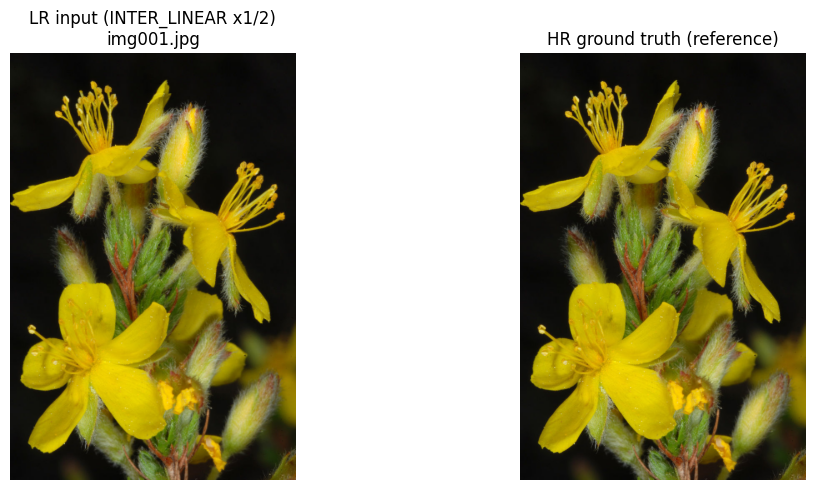

In [ ]:
import matplotlib.pyplot as plt

SAMPLE = subset[0]
hr_img = cv2.imread(os.path.join(test_dir, SAMPLE), cv2.IMREAD_COLOR).astype(np.float32)
hr_ref, lr_input = make_lr(hr_img, UPSCALE)
print(f"sample: {SAMPLE} | HR {hr_ref.shape[1]}x{hr_ref.shape[0]} -> LR {lr_input.shape[1]}x{lr_input.shape[0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(lr_input.astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[0].set_title(f"LR input (INTER_LINEAR x1/{UPSCALE})\n{SAMPLE}")
axes[1].imshow(cv2.cvtColor(hr_ref.astype(np.uint8), cv2.COLOR_BGR2RGB))
axes[1].set_title("HR ground truth (reference)")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Step 9 — Quantitative evaluation: bicubic vs PlantSR ×2

For every subset image we compute PSNR (dB) and SSIM for (a) the authors' bicubic baseline and (b) PlantSR ×2,
always against the mod-cropped HR reference, using the authors' metric code. Results are tabulated, exported to
CSV in the Colab VM (`/content/plantsr_x2_subset_psnr_ssim.csv`), and averaged. The printed reference row is the
paper's **Table 1** ×2 200-image average (Bicubic 38.23 dB / 0.9617; PlantSR 40.36 dB / 0.9716) — our subset
average is expected to be in the same ballpark, not identical.

**日本語:** 各画像について bicubic と PlantSR ×2 の PSNR/SSIM を著者の指標コードで計算し、表と CSV に出力します。
参照値は論文 Table 1(x2、200 枚平均)であり、サブセット平均は目安です。

In [ ]:
import pandas as pd

rows = []
for i, fname in enumerate(subset):
    hr_img = cv2.imread(os.path.join(test_dir, fname), cv2.IMREAD_COLOR).astype(np.float32)
    hr, lr = make_lr(hr_img, UPSCALE)
    h, w, _ = hr.shape

    bic = bicubic_upsample(lr, h, w)
    sr = plantsr_superresolve(lr)

    rows.append({
        "image": fname,
        "psnr_bicubic_dB": calc_psnr(hr, bic),
        "psnr_plantsr_dB": calc_psnr(hr, sr),
        "ssim_bicubic": calc_ssim(hr, bic),
        "ssim_plantsr": calc_ssim(hr, sr),
    })
    print(f"[{i+1}/{len(subset)}] {fname}: PlantSR {rows[-1]['psnr_plantsr_dB']:.2f} dB (bicubic {rows[-1]['psnr_bicubic_dB']:.2f} dB)", flush=True)

df = pd.DataFrame(rows).set_index("image")
print("\nper-image results:")
print(df.round(4).to_string())

means = df.mean(numeric_only=True)
print("\nsubset mean: PSNR bicubic {:.2f} dB | PlantSR {:.2f} dB | SSIM bicubic {:.4f} | PlantSR {:.4f}".format(
    means["psnr_bicubic_dB"], means["psnr_plantsr_dB"], means["ssim_bicubic"], means["ssim_plantsr"]))
print("reference (paper Table 1, x2, 200-image avg): Bicubic 38.23 dB / 0.9617 | PlantSR 40.36 dB / 0.9716")

df.to_csv("/content/plantsr_x2_subset_psnr_ssim.csv")
print("CSV saved to /content/plantsr_x2_subset_psnr_ssim.csv")

[1/8] img001.jpg: PlantSR 38.49 dB (bicubic 37.02 dB)


[2/8] img013.jpg: PlantSR 33.64 dB (bicubic 29.62 dB)


[3/8] img014.jpg: PlantSR 29.46 dB (bicubic 25.86 dB)


[4/8] img040.jpg: PlantSR 31.81 dB (bicubic 30.31 dB)


[5/8] img057.jpg: PlantSR 32.52 dB (bicubic 31.10 dB)


[6/8] img061.jpg: PlantSR 32.44 dB (bicubic 30.70 dB)


[7/8] img063.jpg: PlantSR 47.78 dB (bicubic 46.60 dB)


[8/8] img072.jpg: PlantSR 36.50 dB (bicubic 34.69 dB)



per-image results:
            psnr_bicubic_dB  psnr_plantsr_dB  ssim_bicubic  ssim_plantsr
image                                                                   
img001.jpg          37.0172          38.4917        0.9608        0.9687
img013.jpg          29.6219          33.6420        0.8541        0.9357
img014.jpg          25.8598          29.4555        0.9027        0.9447
img040.jpg          30.3073          31.8075        0.9162        0.9371
img057.jpg          31.0954          32.5195        0.9345        0.9530
img061.jpg          30.6992          32.4423        0.8869        0.9167
img063.jpg          46.6030          47.7788        0.9902        0.9913
img072.jpg          34.6935          36.5035        0.9605        0.9674

subset mean: PSNR bicubic 33.24 dB | PlantSR 35.33 dB | SSIM bicubic 0.9257 | PlantSR 0.9518
reference (paper Table 1, x2, 200-image avg): Bicubic 38.23 dB / 0.9617 | PlantSR 40.36 dB / 0.9716
CSV saved to /content/plantsr_x2_subset_psnr_ssim.csv


## Step 10 — Visual comparison panel

Side-by-side panel for the first subset image: **LR input**, **bicubic upsampling**, **PlantSR ×2 output**
(model prediction), and the **HR ground truth** (reference). PlantSR should recover sharper leaf/organ edges
than bicubic; the difference is exactly the kind of gain quantified by PSNR above. This panel is generated in
Colab from the actual run — it is not a paper figure.

**日本語:** LR 入力 / bicubic / PlantSR ×2 出力 / HR 参照の比較パネルです(この実行から生成)。

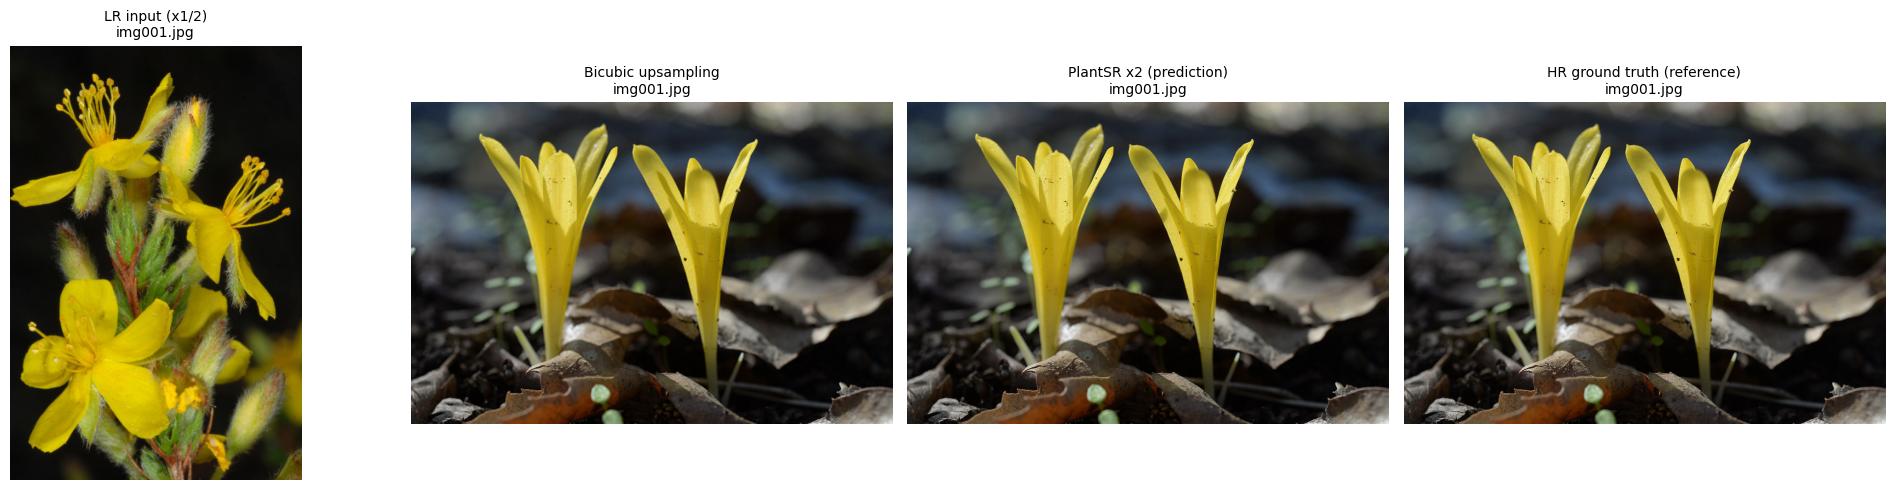

In [ ]:
labels = [
    (lr_input, "LR input (x1/2)"),
    (bic, "Bicubic upsampling"),
    (sr, "PlantSR x2 (prediction)"),
    (hr, "HR ground truth (reference)"),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (img, title) in zip(axes, labels):
    ax.imshow(cv2.cvtColor(np.clip(img, 0, 255).astype(np.uint8), cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title}\n{SAMPLE}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Interpretation and limitations

- **What was executed:** the authors' pretrained PlantSR ×2 model (`PlantSR_x2_best.pth`) ran on a deterministic
  subset of the official PlantSR test split, following the authors' own test protocol and metric code verbatim;
  bicubic baseline and a labeled visual comparison were produced from the same run.
- **Indicative comparison:** the paper reports a 200-image test average of 40.36 dB PSNR / 0.9716 SSIM for
  PlantSR ×2 (bicubic 38.23 / 0.9617). A small subset typically lands near these values; deviations of a few
  tenths of a dB are expected and do not by themselves validate or refute Table 1.
- **Not done here:** training, the full 200-image benchmark, the ×3/×4 scales, and the YOLOv7-apple and
  P2PNet-Soy-soybean counting experiments. Counting improvements are the paper's headline claim and remain
  unverified by this notebook.
- **Provenance & license:** dataset CC BY 4.0 (figshare 24648150 v1); code from github.com/SkyCol/PlantSR commit
  `a514452` — the repository carries **no license file**, so reuse terms are unclarified; weights are the
  authors' public Dropbox release. Metrics/model code is copied verbatim; helper glue is AI-generated and
  follows `test.ipynb` step by step.

**日本語:** 本ノートブックは学習済み ×2 モデルによる推論デモであり、論文の完全な再現ではありません。
サブセット平均は Table 1(200 枚平均)の目安です。カウント実験(本論文の主結果)は未検証です。

## References & validation record

- Q. Lv et al., "PlantSR: Super-Resolution Improves Object Detection in Plant Images," *J. Imaging* 10(6):137, 2024. doi:10.3390/jimaging10060137 (PMC11204869).
- Code: https://github.com/SkyCol/PlantSR — pinned commit `a514452972806aaaf643a111e2d328eb8feb460e` (`models/PlantSR.py`, `calulate_psnr_ssim.py`, `test.ipynb`).
- Dataset: https://figshare.com/articles/dataset/PlantSR_Dataset/24648150 (v1, CC BY 4.0, md5 091964e3e7cd94435c1e499722fde9c2).
- Weights: authors' public Dropbox folder (README "Pretrained models"), `PlantSR_x2_best.pth`, 5,764,873 bytes.
- Validation: fresh Colab run (CPU), all cells executed top-to-bottom; archive paths and measured timings are recorded in the run report.
